# Ecuación de Schrodinger dependiente del tiempo



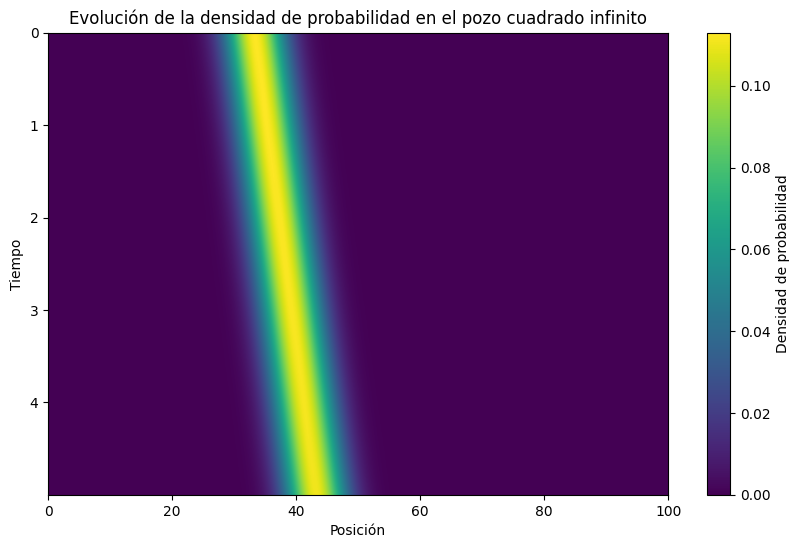

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Parameters
L = 100.0
Nx = 1000
dx = L / (Nx - 1)
dt = 0.001
Nt = 5000

x = np.linspace(0, L, Nx)

# Pozo cuadrado infinito
V = np.zeros(Nx)

# Condiciones iniciales: paquete gaussiano
x0 = L / 3
sigma0 = 5.0
k0 = 2.0

psi0 = np.exp(-0.5 * ((x - x0) / sigma0) ** 2) * np.exp(1j * k0 * x)

# Normalización
norm = np.trapezoid(np.abs(psi0) ** 2, x)
psi0 /= np.sqrt(norm)

# partes reales e imaginarias
R = np.real(psi0)
I = np.imag(psi0)

R_new = np.zeros_like(R)
I_new = np.zeros_like(I)

# probabilidad

rho_history = np.zeros((Nt, Nx))
prob_total = np.zeros(Nt)
beta = dt/dx**2

# Evolución temporal
for n in range(Nt):

    rho_history[n] = R**2 + I**2
    prob_total[n] = np.trapezoid(rho_history[n], x)

    R_new[1:-1] = (R[1:-1] - 0.5*dt*((I[2:] + I[:-2] - 2*I[1:-1]) / dx**2 + V[1:-1]*I[1:-1]))

    R_new[0] = R_new[-1] = 0.0

    I_new[1:-1] = (I[1:-1] + 0.5*dt*((R_new[2:] + R_new[:-2] - 2*R_new[1:-1]) / dx**2 + V[1:-1]*R_new[1:-1]))

    I_new[0] = I_new[-1] = 0.0

    R[:] = R_new
    I[:] = I_new

T = np.arange(Nt) * dt
X, Tmesh = np.meshgrid(x, T)
plt.figure(figsize=(10, 6))
ax = plt.gca()
im = ax.imshow(rho_history, extent=[0, L, T[-1], 0], aspect='auto', cmap='viridis')
plt.colorbar(im, label='Densidad de probabilidad')
ax.set_xlabel('Posición')
ax.set_ylabel('Tiempo')
ax.set_title('Evolución de la densidad de probabilidad en el pozo cuadrado infinito')
plt.show()

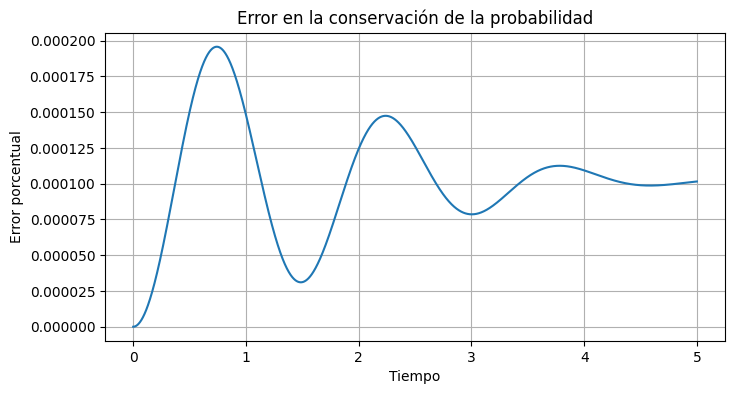

In [4]:
P0 = prob_total[0]
error_percent = ((prob_total - P0) / P0) * 100
plt.figure(figsize=(8, 4))
plt.plot(T, error_percent)
plt.xlabel('Tiempo')
plt.ylabel('Error porcentual')
plt.title('Error en la conservación de la probabilidad')
plt.grid(True)
plt.show()

# Dispersión Coulomb

Note: you may need to restart the kernel to use updated packages.


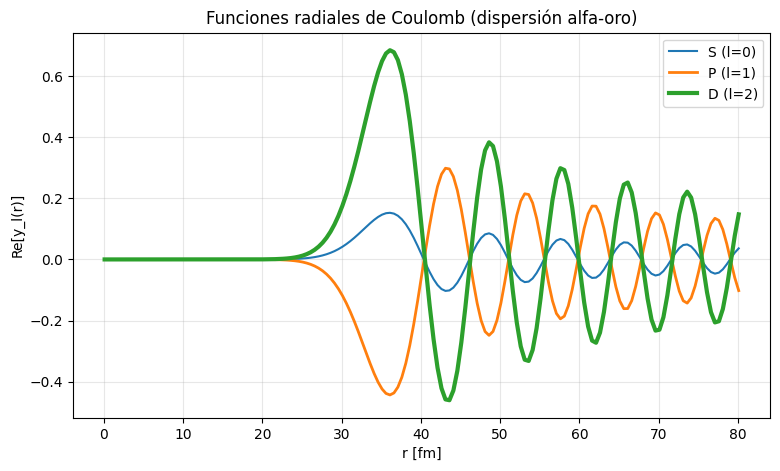

In [10]:
# Instala dependencias del listing de Landau directamente en el kernel actual.
%pip -q install mpmath scipy

import numpy as np
import matplotlib.pyplot as plt
from scipy import special
import mpmath as mp

# Listing 6.17 (Landau) — Funciones de onda regulares de dispersión de Coulomb
# Caso: partícula alfa sobre núcleo de oro (Elab = 7 MeV)
# Unidades: masas en MeV/c^2, hbar*c en MeV·fm, r en fm

# Arreglos para almacenar soluciones parciales (l = 0..9)
f_l = np.zeros(10, dtype=complex)
parte_real = np.zeros((10, 161), dtype=float)

# Unidad imaginaria y parámetros físicos del sistema
zi = complex(0.0, 1.0)
masa_oro = 196.966569 * 931.494
masa_alfa = 4.002602 * 931.494
Z_oro = 79
Z_alfa = 2

# Masa reducida del sistema alfa-oro
masa_reducida = masa_alfa * masa_oro / (masa_alfa + masa_oro)

# Constantes y energía de laboratorio
hbar_c = 197.33
energia_lab = 7.0

# Conversión a energía en centro de masa
energia_cm = energia_lab * masa_oro / (masa_alfa + masa_oro)

# Velocidad relativa y número de onda
velocidad = np.sqrt(2.0 * energia_cm / masa_reducida)
kappa = np.sqrt(2.0 * masa_reducida * energia_cm) / hbar_c

# Parámetro de Coulomb (eta) y factor exponencial de normalización
eta_coulomb = Z_alfa * Z_oro * masa_reducida / (hbar_c * kappa * 137.0)
expo_factor = np.exp(-0.5 * eta_coulomb * np.pi)

# Bucle radial: réplica fiel del esquema de Landau
indice_r = 0
for radio in np.arange(0.1, 80.5, 0.5):
    rho = complex(0.0, -2.0 * kappa * radio)          # -2ikr
    exp_ikr = complex(np.cos(kappa * radio), np.sin(kappa * radio))

    # Bucle en momento angular orbital l = 0..9
    for l in range(0, 10):
        a_param = l + 1.0 + eta_coulomb * zi
        sol_hipergeom = mp.hyp1f1(a_param, 2 * l + 2.0, rho)
        rho_pot_l = (-rho) ** l
        gamma_a = special.gamma(a_param)

        # Amplitud radial compleja regular de Coulomb
        u_parcial = rho_pot_l * exp_ikr * complex(sol_hipergeom) * gamma_a * expo_factor / float(mp.factorial(2 * l))
        f_l[l] = u_parcial / np.sqrt(velocidad)
        parte_real[l, indice_r] = np.real(f_l[l])

    indice_r += 1

# Graficar las primeras tres ondas parciales: S, P y D
r_vals = np.arange(0.1, 80.5, 0.5)
plt.figure(figsize=(9, 5))
plt.plot(r_vals, parte_real[0, :], label='S (l=0)')
plt.plot(r_vals, parte_real[1, :], label='P (l=1)', linewidth=2)
plt.plot(r_vals, parte_real[2, :], label='D (l=2)', linewidth=3)
plt.xlabel('r [fm]')
plt.ylabel('Re[y_l(r)]')
plt.title('Funciones radiales de Coulomb (dispersión alfa-oro)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()